In [11]:
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
from tqdm import tqdm
import gymnasium as gym

In [12]:
env = gym.make('Blackjack-v1', sab=True, render_mode='rgb_array')

In [13]:
done = False
observation, info = env.reset()

In [14]:
action = env.action_space.sample()

observation, reward, terminated, truncated, info = env.step(action)

In [15]:
class BlackjackAgent:
    def __init__(self, learning_rate, initial_epsilon, epsilon_decay, final_epsilon, discount_factor = 0.95):
        self.q_values = defaultdict(lambda: np.zeros(env.action_space.n))
        self.lr = learning_rate
        self.discount_factor = discount_factor
        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon
        self.training_error = []

    def get_action(self, observation): # epsilon-greedy policy
        if np.random.random() < self.epsilon:
            return env.action_space.sample()
        else:
            return int(np.argmax(self.q_values[observation]))
    
    def update(self, observation, action, reward, terminated, next_observation):
        future_q_value = (not terminated) * np.max(self.q_values[next_observation])
        temporal_difference = reward + self.discount_factor * future_q_value - self.q_values[observation][action]

        self.q_values[observation][action] += self.lr * temporal_difference
        self.training_error.append(temporal_difference)
    
    def decay_epsilon(self):
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)

In [16]:
learning_rate = 0.01
n_episodes = 1000
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.1

agent = BlackjackAgent(learning_rate, start_epsilon, epsilon_decay, final_epsilon)

In [17]:
env = gym.wrappers.RecordEpisodeStatistics(env, n_episodes)

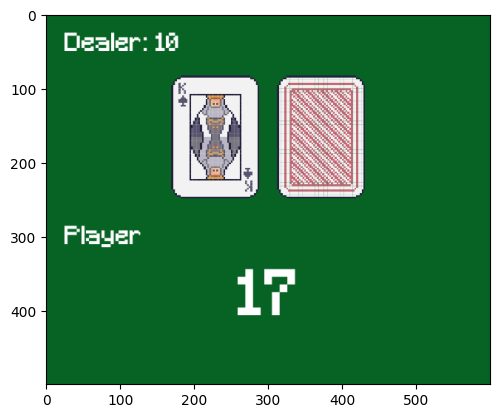

100%|██████████| 1000/1000 [03:20<00:00,  4.98it/s]


In [18]:
from IPython.display import clear_output
for episode in tqdm(range(n_episodes)):
    obs, info = env.reset()
    done = False
    clear_output()

    while not done:
        action = agent.get_action(obs)
        next_obs, reward, terminated, truncated, info = env.step(action)
        agent.update(obs, action, reward, terminated, next_obs)
        frame = env.render()
        plt.imshow(frame)
        plt.show()

        done = terminated or truncated
        obs = next_obs

    agent.decay_epsilon()


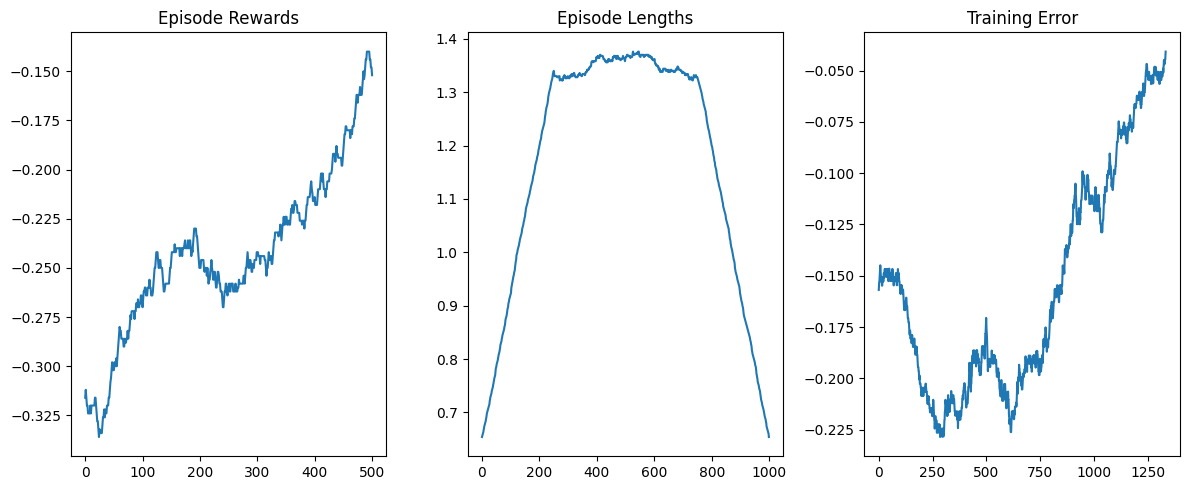

In [19]:
rolling_length = 500
fig, axs = plt.subplots(ncols=3, figsize=(12, 5))
axs[0].set_title('Episode Rewards')
reward_moving_average = (np.convolve(np.array(env.return_queue).flatten(), np.ones(rolling_length), mode='valid')/rolling_length)
axs[0].plot(range(len(reward_moving_average)), reward_moving_average)
axs[1].set_title('Episode Lengths')
length_moving_average = (np.convolve(np.array(env.length_queue).flatten(), np.ones(rolling_length), mode='same')/rolling_length)
axs[1].plot(range(len(length_moving_average)), length_moving_average)
axs[2].set_title('Training Error')
error_moving_average = (np.convolve(np.array(agent.training_error).flatten(), np.ones(rolling_length), mode='same')/rolling_length)
axs[2].plot(range(len(error_moving_average)), error_moving_average)
plt.tight_layout()
plt.show()